# 01 — Data Analysis
## Predictive Hospital Readmission Risk for Chronic Disease Patients

### Objective

Analyze the raw **Diabetes 130-US Hospitals for Years 1999–2008** dataset before preprocessing and machine learning.

### Project Definition

- **Problem:** Predict hospital readmission risk.
- **Target:** `readmitted`
- **Focus:** Readmission within 30 days.
- **Prediction point:** At discharge, using information available from the current hospitalization.
- **Patient tracking:** Not implemented in this prototype.
- **Historical patient-record retrieval:** Not used in the application.

### Target Transformation for Later Modeling

The original target contains:

- `<30` → Readmitted within 30 days
- `>30` → Readmitted after 30 days
- `NO` → Not readmitted

For later binary classification:

- `<30` → `1`
- `>30` → `0`
- `NO` → `0`

### Important

This notebook performs **analysis only**.

It does not:
- modify the raw CSV
- train a machine learning model
- perform final preprocessing
- create the final model

Those tasks will be handled in later notebooks.

## 1. Import Required Libraries

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# Pandas display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Locate and Load the Dataset

In [2]:
# The notebook is normally executed from:
# ml-training/notebooks/

DATA_PATH = Path("../data/diabetic_data.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}\n"
        "Make sure diabetic_data.csv is inside ml-training/data/"
    )

# Read the raw dataset
df = pd.read_csv(DATA_PATH, low_memory=False)

print("Dataset loaded successfully.")
print(f"Path   : {DATA_PATH.resolve()}")
print(f"Rows   : {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset loaded successfully.
Path   : D:\hospital-readmission-project\ml-training\data\diabetic_data.csv
Rows   : 101,766
Columns: 50


## 3. First Look at the Dataset

In [3]:
display(df.head())

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i:02d}. {column}")

Dataset Shape:
(101766, 50)

Column Names:
01. encounter_id
02. patient_nbr
03. race
04. gender
05. age
06. weight
07. admission_type_id
08. discharge_disposition_id
09. admission_source_id
10. time_in_hospital
11. payer_code
12. medical_specialty
13. num_lab_procedures
14. num_procedures
15. num_medications
16. number_outpatient
17. number_emergency
18. number_inpatient
19. diag_1
20. diag_2
21. diag_3
22. number_diagnoses
23. max_glu_serum
24. A1Cresult
25. metformin
26. repaglinide
27. nateglinide
28. chlorpropamide
29. glimepiride
30. acetohexamide
31. glipizide
32. glyburide
33. tolbutamide
34. pioglitazone
35. rosiglitazone
36. acarbose
37. miglitol
38. troglitazone
39. tolazamide
40. examide
41. citoglipton
42. insulin
43. glyburide-metformin
44. glipizide-metformin
45. glimepiride-pioglitazone
46. metformin-rosiglitazone
47. metformin-pioglitazone
48. change
49. diabetesMed
50. readmitted


In [5]:
print("Data Types:")
display(df.dtypes.to_frame(name="Data Type"))

Data Types:


,Data Type
encounter_id,int64
patient_nbr,int64
race,str
gender,str
age,str
weight,str
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64


In [6]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medica

## 4. Check Dataset Schema

The following check verifies that the important columns expected from the UCI dataset are present.

In [7]:
expected_columns = [
    "encounter_id",
    "patient_nbr",
    "race",
    "gender",
    "age",
    "weight",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "payer_code",
    "medical_specialty",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "diag_1",
    "diag_2",
    "diag_3",
    "number_diagnoses",
    "max_glu_serum",
    "A1Cresult",
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone",
    "change",
    "diabetesMed",
    "readmitted",
]

missing_columns = [
    column for column in expected_columns
    if column not in df.columns
]

extra_columns = [
    column for column in df.columns
    if column not in expected_columns
]

print("Expected columns:", len(expected_columns))
print("Actual columns  :", len(df.columns))

print("\nMissing expected columns:")
print(missing_columns if missing_columns else "None")

print("\nAdditional columns:")
print(extra_columns if extra_columns else "None")

Expected columns: 50
Actual columns  : 50

Missing expected columns:
None

Additional columns:
None


## 5. Dataset Quality — Missing Values

The raw UCI CSV commonly represents missing values using `?`.

For analysis, we temporarily convert common missing-value markers to `NaN`.

**Important:** The original `df` is never modified.

In [8]:
MISSING_TOKENS = [
    "?",
    "None",
    "NULL",
    "null",
    "NA",
    "N/A",
    ""
]

# Analysis-only copy
analysis_df = df.replace(MISSING_TOKENS, np.nan)

missing_summary = pd.DataFrame({
    "Missing Count": analysis_df.isna().sum(),
    "Missing Percentage": (analysis_df.isna().mean() * 100)
})

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636
patient_nbr,0,0.000000


In [9]:
# Show only columns that contain missing values

missing_only = missing_summary[
    missing_summary["Missing Count"] > 0
].copy()

display(missing_only)

,Missing Count,Missing Percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


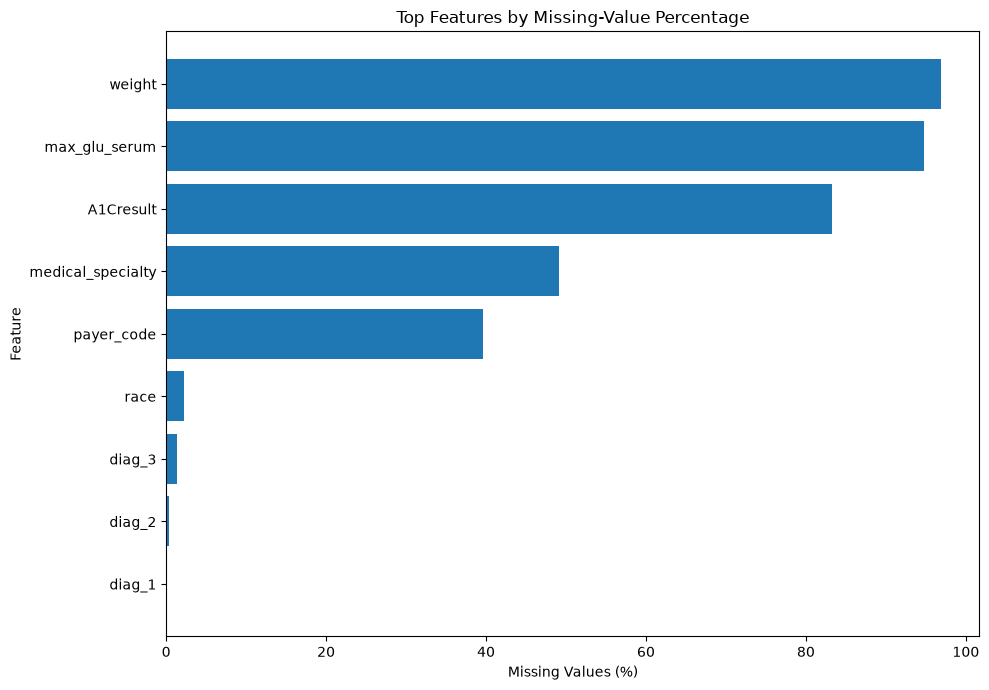

In [10]:
# Visualize top missing-value features

top_missing = (
    missing_summary[missing_summary["Missing Count"] > 0]
    .head(20)
    .sort_values("Missing Percentage", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_missing.index,
    top_missing["Missing Percentage"]
)

plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.title("Top Features by Missing-Value Percentage")

plt.tight_layout()
plt.show()

## 6. Duplicate Analysis

In [12]:
duplicate_rows = df.duplicated().sum()

print(f"Exact duplicate rows: {duplicate_rows:,}")
print(f"Duplicate percentage: {duplicate_rows / len(df) * 100:.4f}%")

Exact duplicate rows: 0
Duplicate percentage: 0.0000%


In [13]:
if "encounter_id" in df.columns:
    duplicate_encounter_ids = df["encounter_id"].duplicated().sum()
    print(f"Duplicate encounter_id values: {duplicate_encounter_ids:,}")

if "patient_nbr" in df.columns:
    unique_patients = df["patient_nbr"].nunique()

    print(f"Unique patients: {unique_patients:,}")
    print(f"Total encounters: {len(df):,}")
    print(
        f"Average encounters per patient: "
        f"{len(df) / unique_patients:.2f}"
    )

Duplicate encounter_id values: 0
Unique patients: 71,518
Total encounters: 101,766
Average encounters per patient: 1.42


### Important Observation

`patient_nbr` may appear multiple times because one patient can have multiple hospital encounters.

Therefore:

- repeated `patient_nbr` does **not** automatically mean duplicate data
- we should not remove records simply because a patient appears multiple times
- `patient_nbr` and `encounter_id` will not be used as ML features

## 7. Target Analysis — `readmitted`

In [14]:
print("Unique target values:")
print(df["readmitted"].unique())

Unique target values:
<StringArray>
['NO', '>30', '<30']
Length: 3, dtype: str


In [15]:
target_counts = df["readmitted"].value_counts(dropna=False)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": (
        target_counts / len(df) * 100
    ).round(2)
})

display(target_summary)

,Count,Percentage
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16


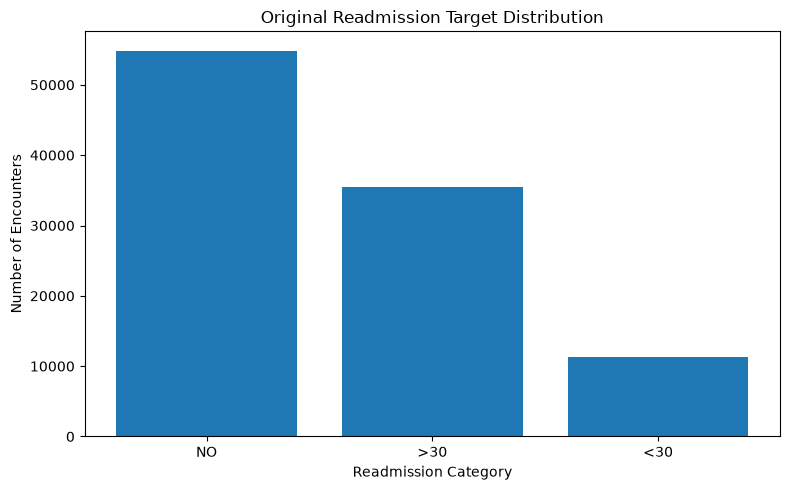

In [16]:
# Target distribution visualization

target_order = ["NO", ">30", "<30"]

existing_order = [
    value for value in target_order
    if value in df["readmitted"].unique()
]

other_values = [
    value for value in df["readmitted"].unique()
    if value not in existing_order
]

plot_order = existing_order + other_values

counts = df["readmitted"].value_counts().reindex(plot_order)

plt.figure(figsize=(8, 5))

plt.bar(
    counts.index.astype(str),
    counts.values
)

plt.xlabel("Readmission Category")
plt.ylabel("Number of Encounters")
plt.title("Original Readmission Target Distribution")

plt.tight_layout()
plt.show()

## 8. Proposed Binary Target

For the actual model, the important event is:

> **Was the patient readmitted within 30 days?**

Therefore we will later transform:

| Original Value | Binary Target | Meaning |
|---|---:|---|
| `<30` | 1 | Readmitted within 30 days |
| `>30` | 0 | Not readmitted within 30 days |
| `NO` | 0 | Not readmitted within 30 days |

The target transformation will be implemented in Notebook 02.

In [18]:
valid_target_values = {"NO", ">30", "<30"}

unexpected_target_values = set(df["readmitted"].dropna().unique()) - valid_target_values

if unexpected_target_values:
    print("Unexpected target values found:")
    print(unexpected_target_values)
else:
    proposed_target = df["readmitted"].map({
        "<30": 1,
        ">30": 0,
        "NO": 0
    })

    binary_target_summary = pd.DataFrame({
        "Class": [0, 1],
        "Meaning": [
            "Not readmitted within 30 days",
            "Readmitted within 30 days"
        ],
        "Count": [
            (proposed_target == 0).sum(),
            (proposed_target == 1).sum()
        ]
    })

    binary_target_summary["Percentage"] = (
        binary_target_summary["Count"]
        / len(proposed_target)
        * 100
    ).round(2)

    display(binary_target_summary)

,Class,Meaning,Count,Percentage
0,0,Not readmitted within 30 days,90409,88.84
1,1,Readmitted within 30 days,11357,11.16


## 9. Feature Cardinality Analysis

This analysis helps identify:

- low-cardinality categorical variables
- high-cardinality variables
- identifier columns
- diagnosis-code complexity

In [19]:
cardinality_summary = pd.DataFrame({
    "Unique Values": analysis_df.nunique(dropna=True),
    "Missing Values": analysis_df.isna().sum(),
})

cardinality_summary = cardinality_summary.sort_values(
    by="Unique Values",
    ascending=False
)

display(cardinality_summary)

,Unique Values,Missing Values
encounter_id,101766,0
patient_nbr,71518,0
diag_3,789,1423
diag_2,748,358
diag_1,716,21
num_lab_procedures,118,0
num_medications,75,0
medical_specialty,72,49949
number_outpatient,39,0
number_emergency,33,0


## 10. Identifier Analysis

The following fields identify records/patients rather than describing their health condition.

They will be excluded from the ML feature set later.

In [20]:
identifier_columns = [
    "encounter_id",
    "patient_nbr"
]

identifier_summary = pd.DataFrame({
    "Feature": identifier_columns,
    "Unique Values": [
        df[column].nunique()
        for column in identifier_columns
    ],
    "Use in Model": [
        "NO",
        "NO"
    ]
})

display(identifier_summary)

,Feature,Unique Values,Use in Model
0,encounter_id,101766,NO
1,patient_nbr,71518,NO


## 11. Categorical Feature Analysis

In [21]:
categorical_features = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "max_glu_serum",
    "A1Cresult",
    "change",
    "diabetesMed",
    "insulin"
]

for column in categorical_features:

    if column not in analysis_df.columns:
        continue

    print("\n" + "=" * 80)
    print(f"FEATURE: {column}")
    print("=" * 80)

    value_counts = (
        analysis_df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .reset_index(name="Count")
    )

    display(value_counts.head(30))


FEATURE: race


,race,Count
0,Caucasian,76099
1,AfricanAmerican,19210
2,NaN,2273
3,Hispanic,2037
4,Other,1506
5,Asian,641



FEATURE: gender


,gender,Count
0,Female,54708
1,Male,47055
2,Unknown/Invalid,3



FEATURE: age


...

,change,Count
0,No,54755
1,Ch,47011



FEATURE: diabetesMed


,diabetesMed,Count
0,Yes,78363
1,No,23403



FEATURE: insulin


,insulin,Count
0,No,47383
1,Steady,30849
2,Down,12218
3,Up,11316


## 12. Numerical / Count Feature Analysis

In [22]:
numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

numeric_summary = []

for column in numeric_features:

    numeric_values = pd.to_numeric(
        analysis_df[column],
        errors="coerce"
    )

    numeric_summary.append({
        "Feature": column,
        "Non-Null": numeric_values.notna().sum(),
        "Missing": numeric_values.isna().sum(),
        "Mean": numeric_values.mean(),
        "Median": numeric_values.median(),
        "Std": numeric_values.std(),
        "Min": numeric_values.min(),
        "Max": numeric_values.max()
    })

numeric_summary = pd.DataFrame(numeric_summary)

display(numeric_summary.round(3))

,Feature,Non-Null,Missing,Mean,Median,Std,Min,Max
0,time_in_hospital,101766,0,4.396,4.0,2.985,1,14
1,num_lab_procedures,101766,0,43.096,44.0,19.674,1,132
2,num_procedures,101766,0,1.340,1.0,1.706,0,6
3,num_medications,101766,0,16.022,15.0,8.128,1,81
4,number_outpatient,101766,0,0.369,0.0,1.267,0,42
5,number_emergency,101766,0,0.198,0.0,0.930,0,76
6,number_inpatient,101766,0,0.636,0.0,1.263,0,21
7,number_diagnoses,101766,0,7.423,8.0,1.934,1,16


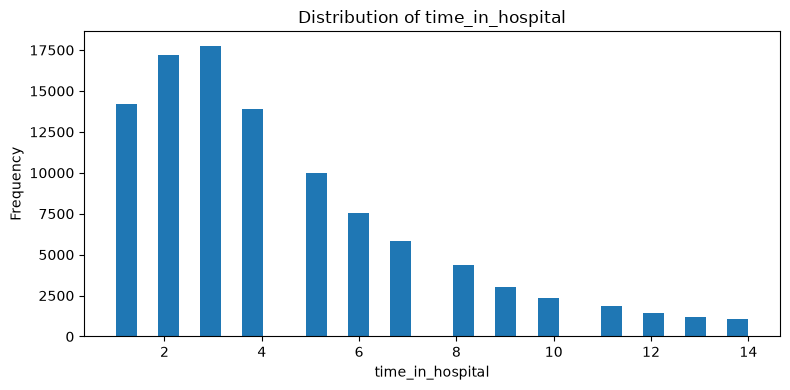

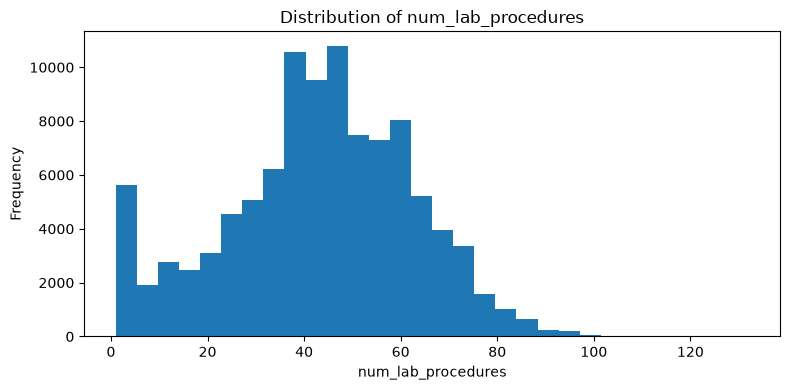

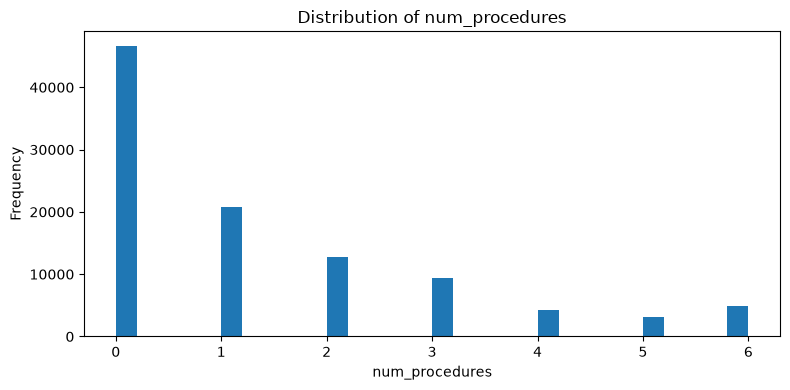

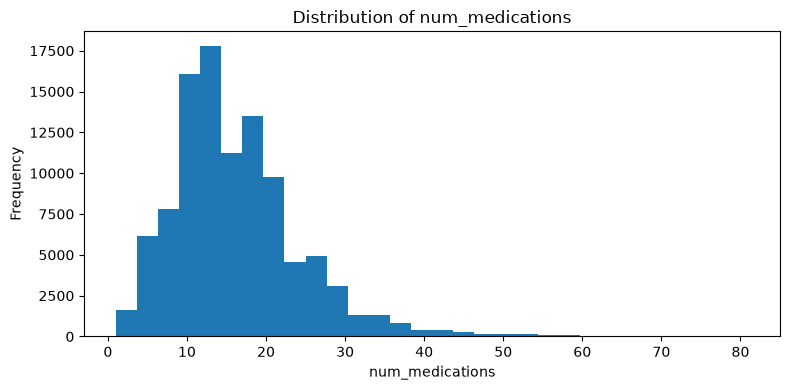

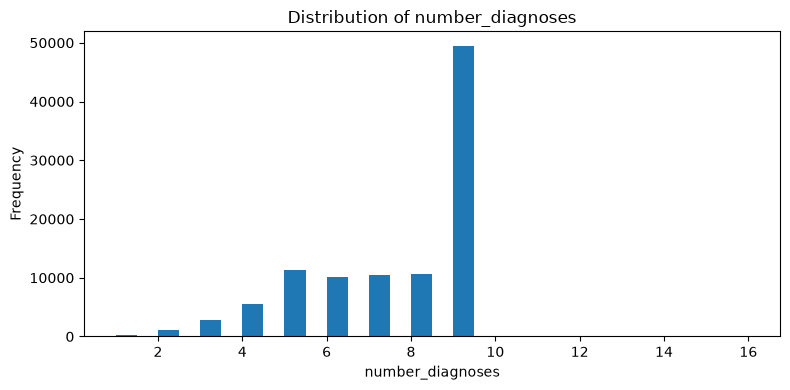

In [23]:
numeric_plot_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses"
]

for column in numeric_plot_features:

    values = pd.to_numeric(
        analysis_df[column],
        errors="coerce"
    ).dropna()

    plt.figure(figsize=(8, 4))

    plt.hist(
        values,
        bins=30
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}")

    plt.tight_layout()
    plt.show()

## 13. Readmission Rate by Important Features

This section is for **exploratory analysis**.

It checks whether the 30-day readmission rate differs across categories.

### Important

A relationship between a feature and readmission does **not** prove that the feature causes readmission.

Actual model importance will be evaluated later.

In [24]:
analysis_df["readmitted_30_analysis"] = (
    analysis_df["readmitted"]
    .map({
        "<30": 1,
        ">30": 0,
        "NO": 0
    })
)

features_for_readmission_analysis = [
    "age",
    "gender",
    "admission_type_id",
    "admission_source_id",
    "A1Cresult",
    "max_glu_serum",
    "diabetesMed",
    "change",
    "insulin",
    "discharge_disposition_id"
]

for column in features_for_readmission_analysis:

    if column not in analysis_df.columns:
        continue

    rate_table = (
        analysis_df
        .groupby(
            column,
            dropna=False
        )["readmitted_30_analysis"]
        .agg(
            Count="count",
            Readmission_Rate="mean"
        )
        .sort_values(
            "Readmission_Rate",
            ascending=False
        )
    )

    rate_table["Readmission_Rate"] = (
        rate_table["Readmission_Rate"] * 100
    ).round(2)

    print("\n" + "=" * 80)
    print(f"30-DAY READMISSION RATE BY: {column}")
    print("=" * 80)

    display(rate_table.head(30))


30-DAY READMISSION RATE BY: age


,Count,Readmission_Rate
age,,
[20-30),1657,14.24
[80-90),17197,12.08
[70-80),26068,11.77
[30-40),3775,11.23
[60-70),22483,11.13
[90-100),2793,11.10
[40-50),9685,10.60
[50-60),17256,9.67
[10-20),691,5.79



30-DAY READMISSION RATE BY: gender


,Count,Readmission_Rate
gender,,
Female,54708,11.25
Male,47055,11.06
Unknown/Invalid,3,0.00



30-DAY READMISSION RATE BY: admission_type_id


...

,Count,Readmission_Rate
change,,
Ch,47011,11.82
No,54755,10.59



30-DAY READMISSION RATE BY: insulin


,Count,Readmission_Rate
insulin,,
Down,12218,13.90
Up,11316,12.99
Steady,30849,11.13
No,47383,10.04



30-DAY READMISSION RATE BY: discharge_disposition_id


,Count,Readmission_Rate
discharge_disposition_id,,
12,3,66.67
15,63,44.44
9,21,42.86
28,139,36.69
22,1993,27.70
5,1184,20.86
2,2128,16.07
3,13954,14.66
24,48,14.58


## 14. Numerical Features vs 30-Day Readmission

We compare numerical feature distributions between:

- `0` → Not readmitted within 30 days
- `1` → Readmitted within 30 days

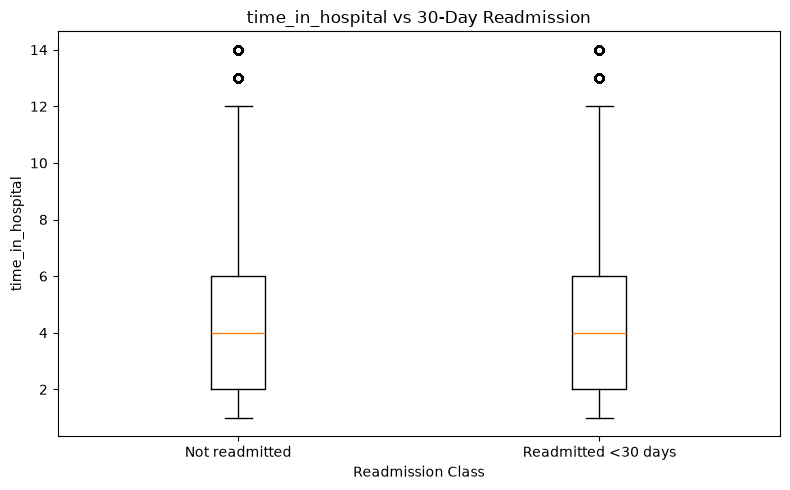

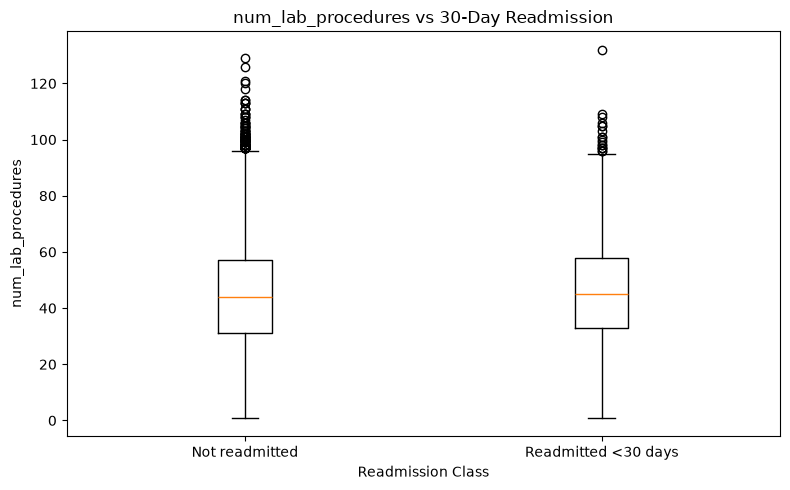

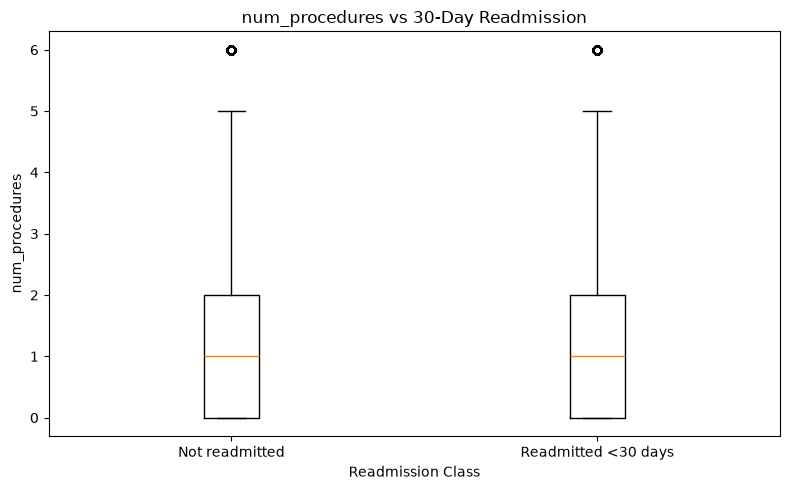

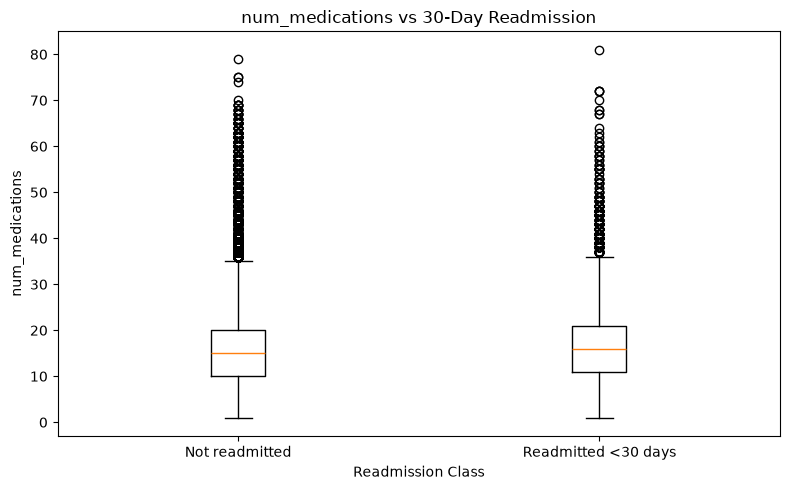

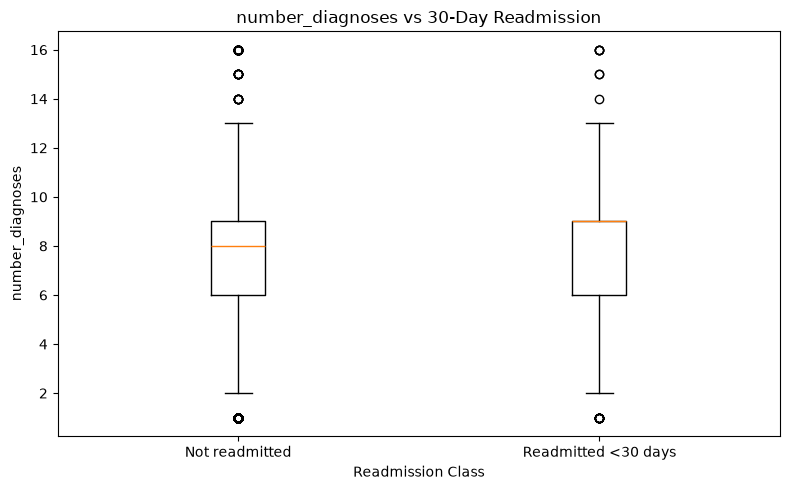

In [26]:
analysis_numeric_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_diagnoses"
]

for column in analysis_numeric_features:

    values = pd.to_numeric(
        analysis_df[column],
        errors="coerce"
    )

    group_0 = values[
        analysis_df["readmitted_30_analysis"] == 0
    ].dropna()

    group_1 = values[
        analysis_df["readmitted_30_analysis"] == 1
    ].dropna()

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        [group_0, group_1],
        tick_labels=[             # Changed from 'labels' to 'tick_labels'
            "Not readmitted",
            "Readmitted <30 days"
        ]
    )

    plt.xlabel("Readmission Class")
    plt.ylabel(column)
    plt.title(f"{column} vs 30-Day Readmission")

    plt.tight_layout()
    plt.show()

## 15. Medication Feature Overview

The dataset contains many individual diabetes medication columns.

We inspect them here, but we do not make the final decision about how to represent them until Notebook 02.

In [27]:
medication_columns = [
    "metformin",
    "repaglinide",
    "nateglinide",
    "chlorpropamide",
    "glimepiride",
    "acetohexamide",
    "glipizide",
    "glyburide",
    "tolbutamide",
    "pioglitazone",
    "rosiglitazone",
    "acarbose",
    "miglitol",
    "troglitazone",
    "tolazamide",
    "examide",
    "citoglipton",
    "insulin",
    "glyburide-metformin",
    "glipizide-metformin",
    "glimepiride-pioglitazone",
    "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

available_medication_columns = [
    column
    for column in medication_columns
    if column in df.columns
]

medication_summary = pd.DataFrame({
    "Feature": available_medication_columns,
    "Unique Values": [
        df[column].nunique(dropna=True)
        for column in available_medication_columns
    ],
    "Missing Percentage": [
        analysis_df[column].isna().mean() * 100
        for column in available_medication_columns
    ]
})

medication_summary["Missing Percentage"] = (
    medication_summary["Missing Percentage"].round(2)
)

display(medication_summary)

,Feature,Unique Values,Missing Percentage
0,metformin,4,0.0
1,repaglinide,4,0.0
2,nateglinide,4,0.0
3,chlorpropamide,4,0.0
4,glimepiride,4,0.0
5,acetohexamide,2,0.0
6,glipizide,4,0.0
7,glyburide,4,0.0
8,tolbutamide,2,0.0
9,pioglitazone,4,0.0


## 16. Preliminary Feature Screening

This is an **initial project-oriented screening**, not the final feature selection.

### Exclude
- `encounter_id`
- `patient_nbr`

These are identifiers.

### Exclude for the current prototype
- `number_outpatient`
- `number_emergency`
- `number_inpatient`

These describe previous healthcare utilization. Our current prototype does not track or retrieve a patient's previous records.

### Candidate current-encounter features
- demographic information
- admission information
- diagnoses
- laboratory results
- hospitalization information
- treatment/medication information
- discharge information

The final feature set will be finalized in Notebook 02 after checking missing values, encoding requirements, feature representation, and prediction-time availability.

In [28]:
feature_screening = pd.DataFrame([
    ["age", "Candidate", "Patient demographic information"],
    ["gender", "Candidate", "Patient demographic information"],
    ["race", "Review", "Demographic feature; assess predictive contribution and fairness"],
    
    ["admission_type_id", "Candidate", "Current admission information"],
    ["admission_source_id", "Candidate", "Current admission source"],
    
    ["diag_1", "Candidate", "Primary diagnosis"],
    ["diag_2", "Candidate", "Secondary diagnosis"],
    ["diag_3", "Candidate", "Additional diagnosis"],
    ["number_diagnoses", "Candidate", "Overall diagnostic complexity"],
    
    ["A1Cresult", "Candidate", "Diabetes-related laboratory information"],
    ["max_glu_serum", "Candidate", "Glucose-related laboratory information"],
    
    ["time_in_hospital", "Candidate", "Current hospitalization duration"],
    ["num_lab_procedures", "Candidate", "Current hospitalization activity"],
    ["num_procedures", "Candidate", "Current hospitalization procedures"],
    ["num_medications", "Candidate", "Current treatment complexity"],
    
    ["diabetesMed", "Candidate", "Diabetes treatment information"],
    ["change", "Candidate", "Medication change during encounter"],
    ["insulin", "Candidate", "Insulin treatment status"],
    
    ["discharge_disposition_id", "Candidate", "Discharge information"],
    
    ["number_outpatient", "Exclude", "Previous healthcare utilization"],
    ["number_emergency", "Exclude", "Previous healthcare utilization"],
    ["number_inpatient", "Exclude", "Previous healthcare utilization"],
    
    ["encounter_id", "Exclude", "Identifier"],
    ["patient_nbr", "Exclude", "Identifier"],
    
    ["weight", "Review", "Potentially useful but highly incomplete"],
    ["payer_code", "Review", "Administrative feature with substantial missingness"],
    ["medical_specialty", "Review", "Potentially useful but highly sparse"]
], columns=[
    "Feature",
    "Initial Decision",
    "Reason"
])

display(feature_screening)

,Feature,Initial Decision,Reason
0,age,Candidate,Patient demographic information
1,gender,Candidate,Patient demographic information
2,race,Review,Demographic feature; assess predictive contribution and fairness
3,admission_type_id,Candidate,Current admission information
4,admission_source_id,Candidate,Current admission source
5,diag_1,Candidate,Primary diagnosis
6,diag_2,Candidate,Secondary diagnosis
7,diag_3,Candidate,Additional diagnosis
8,number_diagnoses,Candidate,Overall diagnostic complexity
9,A1Cresult,Candidate,Diabetes-related laboratory information


# 17. Analysis Summary

### Dataset

The raw dataset contains hospital encounter information for diabetic patients.

### Target

`readmitted`

Original classes:

- `NO`
- `>30`
- `<30`

For the later model:

- `<30` = positive class
- `>30` and `NO` = negative class

### Important feature groups

#### Patient
- age
- gender
- race

#### Admission
- admission_type_id
- admission_source_id

#### Clinical
- diag_1
- diag_2
- diag_3
- number_diagnoses

#### Laboratory
- A1Cresult
- max_glu_serum

#### Hospitalization
- time_in_hospital
- num_lab_procedures
- num_procedures
- num_medications

#### Treatment
- diabetesMed
- change
- insulin
- individual medication fields

#### Discharge
- discharge_disposition_id

### Features excluded from the current prototype

- encounter_id
- patient_nbr
- number_outpatient
- number_emergency
- number_inpatient
